In [2]:
from importlib import util

if util.find_spec("starforge") is None:
    ! cd ../ && pip install -e .

In [3]:

import matplotlib.pyplot as plt
import numpy as np
from starforge.cosmology import LCDMModel
from starforge.cosmology import CosmologicalParameters
from starforge.structures import PressSchechterMF
from starforge.structures import Perturbations
from starforge.structures import  Sigma
from starforge.structures import HaloBaryonAccretion
from starforge.sfr import SFR
from starforge.observational.sfr import ObservationalCSFR

/home/eduardo/Projects/starforge/.venv/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [4]:
obs_csfr = ObservationalCSFR()
z_obs, csfr_obs = obs_csfr.csf_redshift()
xerr, yerr = obs_csfr.error_data()

params = CosmologicalParameters(
    omegam=0.24,
    omegab=0.04,
    omegal=0.73,
    h=0.7   
)
zmax = 20

lcdm = LCDMModel(params)

pert = Perturbations(lcdm)

sigma = Sigma(pert)

## Criando função de massa de halos
# Usamos HalosMassFunction, que depende de Sigma e Perturbations internamente.

sigma_functions = sigma.initialize_sigma_cache(
    zmax=zmax,
    mass_function_type="ST",  # Sheth-Tormen, por exemplo
    lmin=6.0,                 # log10(M_min / Msun)
    lmax=18.0,                # log10(M_max / Msun)
    dinamicLimits=True,
)

mass_function = PressSchechterMF(lcdm, pert, sigma_functions)

hba = HaloBaryonAccretion(mass_function, zmax=zmax)

# Inicializar factory
csfr_model =  SFR(
            halo_acc=hba,
            tau=2.0, eimf=1.35, nsch=1, imf_type="S", zmax=zmax, 
        )


In [5]:


# %%
# 5. Calcular CSFR(z) para um grid de redshifts
z_vals = np.linspace(0, 20, 100)
csfr_vals = [csfr_model.cosmic_star_formation_rate(z) for z in z_vals]
rho_gas_vals = [csfr_model.gas_density_in_structures(z) for z in z_vals]



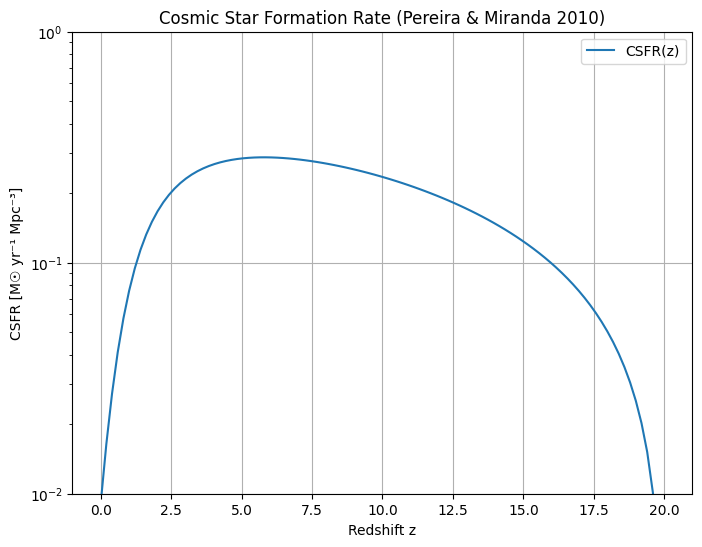

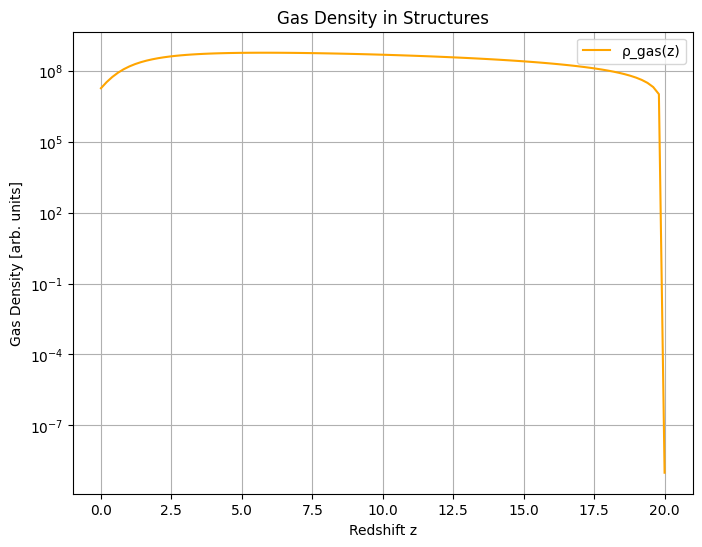

In [6]:
# %%
# 6. Plotar os resultados
plt.figure(figsize=(8,6))
plt.plot(z_vals, csfr_vals, label="CSFR(z)")
plt.ylim([0.01, 1])
plt.xlabel("Redshift z")
plt.ylabel("CSFR [M☉ yr⁻¹ Mpc⁻³]")
plt.yscale("log")   # Escala logarítmica no eixo Y

plt.title("Cosmic Star Formation Rate (Pereira & Miranda 2010)")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(z_vals, rho_gas_vals, label="ρ_gas(z)", color="orange")
plt.xlabel("Redshift z")
plt.ylabel("Gas Density [arb. units]")
plt.title("Gas Density in Structures")
plt.yscale("log")   # Escala logarítmica no eixo Y

plt.legend()
plt.grid()
plt.show()

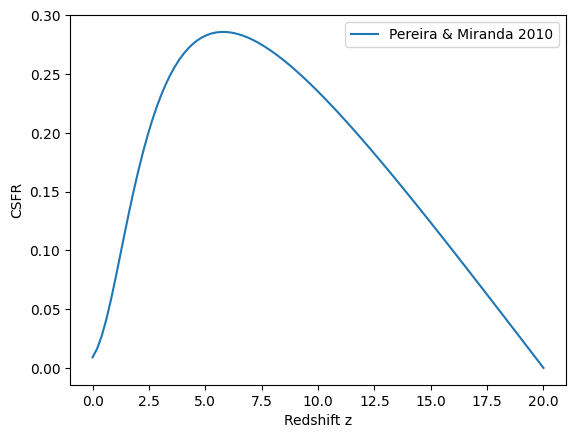

In [7]:

plt.plot(z_vals, csfr_vals, label="Pereira & Miranda 2010")
plt.xlabel("Redshift z")
plt.ylabel("CSFR")
plt.legend()
plt.show()

In [8]:
z_grid = np.linspace(0, 10, 200)
csfr_theory = [csfr_model.cosmic_star_formation_rate(z) for z in z_grid]

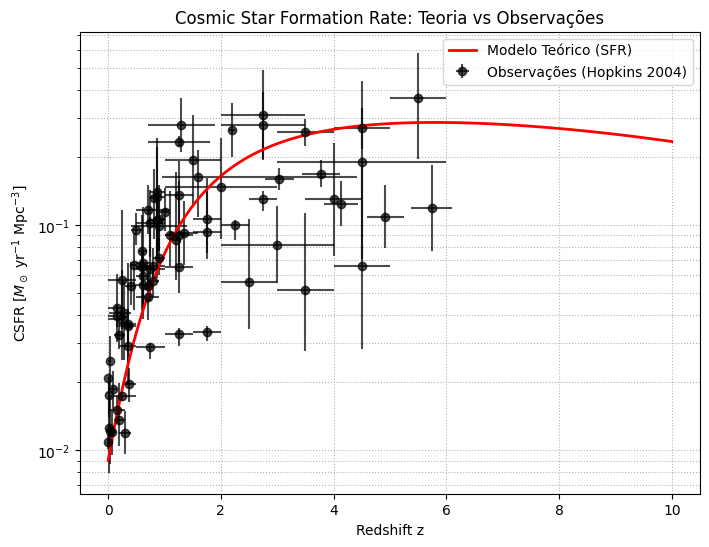

In [9]:
plt.figure(figsize=(8, 6))


# Dados observacionais
plt.errorbar(
z_obs, csfr_obs,
xerr=xerr, yerr=yerr,
fmt="o", color="black", label="Observações (Hopkins 2004)", alpha=0.7
)


# Curva teórica
plt.plot(z_grid, csfr_theory, color="red", lw=2, label="Modelo Teórico (SFR)")


plt.yscale("log")
plt.xlabel("Redshift z")
plt.ylabel(r"CSFR [$M_\odot$ yr$^{-1}$ Mpc$^{-3}$]")
plt.title("Cosmic Star Formation Rate: Teoria vs Observações")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()